
# Probability Concepts in Python 📘

This notebook covers core probability concepts useful in machine learning, with runnable Python examples:
- Sample space
- Events
- Joint probability
- Conditional probability
- Bayes' theorem
- Visual examples and short exercises

All plots use `matplotlib` and code is ready to run.



## 1. Sample Space

The **sample space (S)** is the set of all possible outcomes of a random experiment.
Examples and code:


In [1]:

# Sample space examples
coin = ['Heads', 'Tails']
die = list(range(1,7))

print("Coin sample space:", coin)
print("Die sample space:", die)

# In ML, a sample space might be the set of all labels or all possible input discretizations.


Coin sample space: ['Heads', 'Tails']
Die sample space: [1, 2, 3, 4, 5, 6]



## 2. Events

An **event** is a subset of the sample space. We'll compute probabilities by counting outcomes (uniform discrete examples).


In [ ]:

# Example: Rolling a fair die
S = list(range(1,7))
event_even = {2,4,6}

P_S = 1 / len(S)            # each outcome 1/6
P_event_even = len(event_even) / len(S)
P_event_even



## 3. Joint Probability

**Joint probability** P(A and B) is the probability that both events occur simultaneously.
We'll illustrate with two discrete variables: 'weather' and 'market up/down' (toy example).


In [1]:

# Toy joint distribution as a table (discrete)
import pandas as pd

# Rows: Weather = {Sunny, Rainy}, Columns: Market = {Up, Down}
data = {'Market_Up': [0.30, 0.10], 'Market_Down': [0.20, 0.40]}
joint_df = pd.DataFrame(data, index=['Sunny','Rainy'])
joint_df.index.name = 'Weather'
joint_df


,Market_Up,Market_Down
Weather,,
Sunny,0.3,0.2
Rainy,0.1,0.4



Verify that the table sums to 1 (valid joint distribution), and compute marginal probabilities.


In [2]:

# Check sum to 1 and compute marginals
joint_df = joint_df.astype(float)
total = joint_df.values.sum()
marginal_weather = joint_df.sum(axis=1)  # P(Weather)
marginal_market = joint_df.sum(axis=0)   # P(Market)
total, marginal_weather, marginal_market


(np.float64(1.0),
 Weather
 Sunny    0.5
 Rainy    0.5
 dtype: float64,
 Market_Up      0.4
 Market_Down    0.6
 dtype: float64)


## 4. Conditional Probability

Conditional probability: \(P(A|B) = \frac{P(A, B)}{P(B)}\).

From the joint table above, compute P(Market=Up | Weather=Sunny).


In [ ]:

# P(Market=Up | Weather=Sunny)
p_market_up_and_sunny = joint_df.loc['Sunny', 'Market_Up']
p_sunny = marginal_weather['Sunny']
p_market_up_given_sunny = p_market_up_and_sunny / p_sunny
p_market_up_and_sunny, p_sunny, p_market_up_given_sunny



## 5. Bayes' Theorem

Bayes' theorem updates beliefs:
\[ P(A|B) = \frac{P(B|A) P(A)}{P(B)} \]

We'll use a financial example (loan default) similar to prior discussion to compute P(Default | Flagged).


In [1]:

# Bayes' theorem example (loan default)
p_default = 0.05
p_flagged_given_default = 0.90
p_flagged_given_not_default = 0.20

p_flagged = p_flagged_given_default * p_default + p_flagged_given_not_default * (1 - p_default)
p_default_given_flagged = (p_flagged_given_default * p_default) / p_flagged

p_flagged, p_default_given_flagged


(0.23500000000000001, 0.19148936170212766)


## 6. Visualizing Distributions

We'll visualize a simple joint distribution as a heatmap-like plot using `matplotlib`.
(We will not use seaborn in this notebook; matplotlib only.)


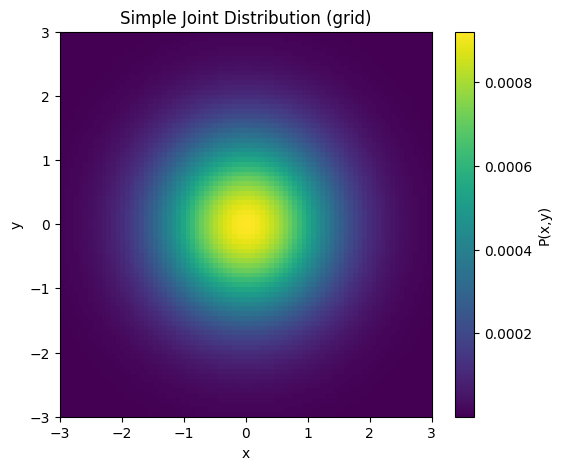

In [2]:

import numpy as np
import matplotlib.pyplot as plt

# Simple grid joint distribution (normalized)
x = np.linspace(-3,3,80)
y = np.linspace(-3,3,80)
X, Y = np.meshgrid(x,y)
Z = np.exp(-(X**2 + Y**2)/2.0)  # unnormalized joint
Z = Z / Z.sum()

plt.figure(figsize=(6,5))
plt.imshow(Z, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()], aspect='auto')
plt.title('Simple Joint Distribution (grid)')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='P(x,y)')
plt.show()



## 7. Short Exercises

1. Suppose a classifier has 1% false positive rate and 95% true positive rate. If the base rate of the condition is 0.5%, compute the posterior probability of the condition given a positive test.
2. Create a joint distribution for three binary features (A,B,C) with 8 probabilities that sum to 1. Compute P(A=1 | B=1).
3. Simulate 10,000 coin flips and estimate the probability of getting exactly 5 heads out of 10.

Try solving them in new notebook cells below.


In [3]:

# Exercise 1 solution (worked example)
p_condition = 0.005
tpr = 0.95  # true positive rate P(+|cond)
fpr = 0.01  # false positive rate P(+|not cond)

p_positive = tpr * p_condition + fpr * (1 - p_condition)
p_condition_given_positive = (tpr * p_condition) / p_positive
p_positive, p_condition_given_positive


(0.014700000000000001, 0.32312925170068024)

In [4]:

# Exercise 3 (simulation example)
import random
import numpy as np

def simulate_coin_flips(trials=10000, n=10, target_heads=5):
    counts = 0
    for _ in range(trials):
        flips = np.random.rand(n) < 0.5
        if flips.sum() == target_heads:
            counts += 1
    return counts / trials

simulate_coin_flips()


0.2475


---
### Further reading & next steps
- *Probability and Statistics for Engineers and Scientists* — good textbook
- Study how probability underlies models: Naive Bayes, Bayesian networks, HMMs, probabilistic deep learning.
- Try converting discrete examples to continuous ones (PDFs, densities) and practice computing integrals numerically.
